# importing all the libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Data Loading

In [2]:
gen = pd.read_csv('Plant_1_Generation_Data.csv')
weather = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

In [3]:
gen

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.000,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.000,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.000,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.000,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.000,7158964.0
...,...,...,...,...,...,...,...
68773,17-06-2020 23:45,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,17-06-2020 23:45,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,17-06-2020 23:45,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,17-06-2020 23:45,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0


In [4]:
weather

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0
...,...,...,...,...,...,...
3177,2020-06-17 22:45:00,4135001,HmiyD2TTLFNqkNe,22.150570,21.480377,0.0
3178,2020-06-17 23:00:00,4135001,HmiyD2TTLFNqkNe,22.129816,21.389024,0.0
3179,2020-06-17 23:15:00,4135001,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
3180,2020-06-17 23:30:00,4135001,HmiyD2TTLFNqkNe,21.969495,20.734963,0.0


In [5]:
gen['DATE_TIME'] = pd.to_datetime(
    gen['DATE_TIME'],
    format='%d-%m-%Y %H:%M'
)

weather['DATE_TIME'] = pd.to_datetime(
    weather['DATE_TIME']
)

In [6]:
gen

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.000,6259559.0
1,2020-05-15 00:00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.000,6183645.0
2,2020-05-15 00:00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.000,6987759.0
3,2020-05-15 00:00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.000,7602960.0
4,2020-05-15 00:00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.000,7158964.0
...,...,...,...,...,...,...,...
68773,2020-06-17 23:45:00,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,2020-06-17 23:45:00,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,2020-06-17 23:45:00,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,2020-06-17 23:45:00,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0


In [7]:
gen['DATE_TIME'].dtype

dtype('<M8[us]')

In [8]:
weather

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0
...,...,...,...,...,...,...
3177,2020-06-17 22:45:00,4135001,HmiyD2TTLFNqkNe,22.150570,21.480377,0.0
3178,2020-06-17 23:00:00,4135001,HmiyD2TTLFNqkNe,22.129816,21.389024,0.0
3179,2020-06-17 23:15:00,4135001,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
3180,2020-06-17 23:30:00,4135001,HmiyD2TTLFNqkNe,21.969495,20.734963,0.0


In [9]:
merged_df = pd.merge(
    gen,
    weather,
    on=["DATE_TIME", "PLANT_ID"],
    how="inner"
)

In [10]:
merged_df

,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.000,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.000,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15 00:00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.000,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15 00:00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.000,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15 00:00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.000,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
...,...,...,...,...,...,...,...,...,...,...,...
68769,2020-06-17 23:45:00,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0
68770,2020-06-17 23:45:00,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0
68771,2020-06-17 23:45:00,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0
68772,2020-06-17 23:45:00,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0


# Data Info Gathering

In [11]:
merged_df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [12]:
merged_df.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
68769,2020-06-17 23:45:00,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0
68770,2020-06-17 23:45:00,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0
68771,2020-06-17 23:45:00,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0
68772,2020-06-17 23:45:00,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0
68773,2020-06-17 23:45:00,4135001,zVJPv84UY57bAof,0.0,0.0,5910.000,7363272.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0


In [13]:
merged_df.info()  #Info of our dataset

<class 'pandas.DataFrame'>
RangeIndex: 68774 entries, 0 to 68773
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            68774 non-null  datetime64[us]
 1   PLANT_ID             68774 non-null  int64         
 2   SOURCE_KEY_x         68774 non-null  str           
 3   DC_POWER             68774 non-null  float64       
 4   AC_POWER             68774 non-null  float64       
 5   DAILY_YIELD          68774 non-null  float64       
 6   TOTAL_YIELD          68774 non-null  float64       
 7   SOURCE_KEY_y         68774 non-null  str           
 8   AMBIENT_TEMPERATURE  68774 non-null  float64       
 9   MODULE_TEMPERATURE   68774 non-null  float64       
 10  IRRADIATION          68774 non-null  float64       
dtypes: datetime64[us](1), float64(7), int64(1), str(2)
memory usage: 5.8 MB


In [14]:
merged_df.shape   # tells the shape(rows,columns) of dataset

(68774, 11)

In [15]:
merged_df.describe()    #describes the whole

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,68774,68774.0,68774.000000,68774.000000,68774.000000,6.877400e+04,68774.000000,68774.000000,68774.000000
mean,2020-06-01 08:02:38.161514,4135001.0,3147.177450,307.778375,3295.834644,6.978728e+06,25.558521,31.244997,0.232305
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06,20.398505,18.140415,0.000000
25%,2020-05-24 00:33:45,4135001.0,0.000000,0.000000,0.000000,6.512007e+06,22.724491,21.123944,0.000000
50%,2020-06-01 14:15:00,4135001.0,428.571429,41.450000,2658.473214,7.146685e+06,24.670178,24.818984,0.031620
75%,2020-06-09 20:00:00,4135001.0,6365.468750,623.561161,6274.000000,7.268751e+06,27.960429,41.693659,0.454880
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06,35.252486,65.545714,1.221652
std,NaN,0.0,4036.441826,394.394865,3145.220597,4.162707e+05,3.361300,12.308283,0.301948


In [16]:
print(gen['DATE_TIME'].head())
print(weather['DATE_TIME'].head())

0   2020-05-15
1   2020-05-15
2   2020-05-15
3   2020-05-15
4   2020-05-15
Name: DATE_TIME, dtype: datetime64[us]
0   2020-05-15 00:00:00
1   2020-05-15 00:15:00
2   2020-05-15 00:30:00
3   2020-05-15 00:45:00
4   2020-05-15 01:00:00
Name: DATE_TIME, dtype: datetime64[us]


# Data Cleaning

In [17]:
merged_df.loc[0, 'DATE_TIME']

Timestamp('2020-05-15 00:00:00')

In [18]:
merged_df.duplicated().sum()

np.int64(0)

In [19]:
merged_df.isnull().sum()

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY_x           0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
SOURCE_KEY_y           0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

# Data Visualization

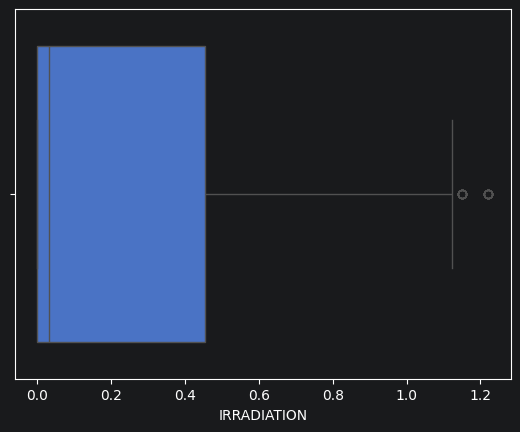

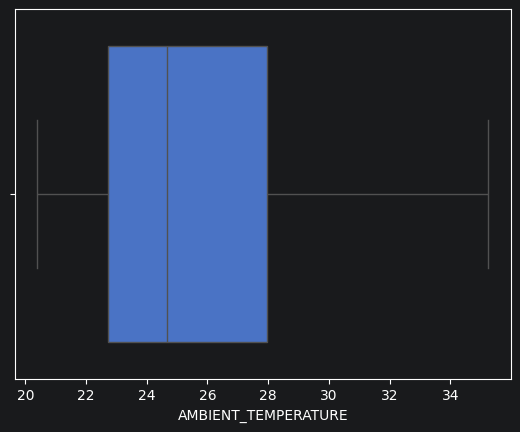

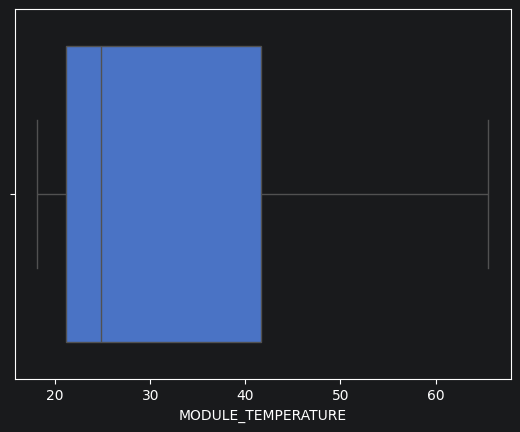

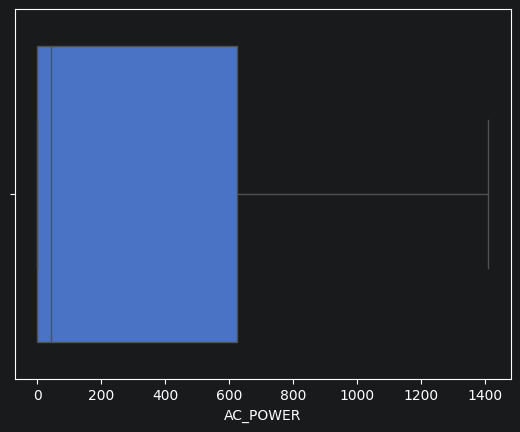

In [20]:
sns.boxplot(x=merged_df['IRRADIATION'])
plt.show()

sns.boxplot(x=merged_df['AMBIENT_TEMPERATURE'])
plt.show()

sns.boxplot(x=merged_df['MODULE_TEMPERATURE'])
plt.show()

sns.boxplot(x=merged_df['AC_POWER'])
plt.show()

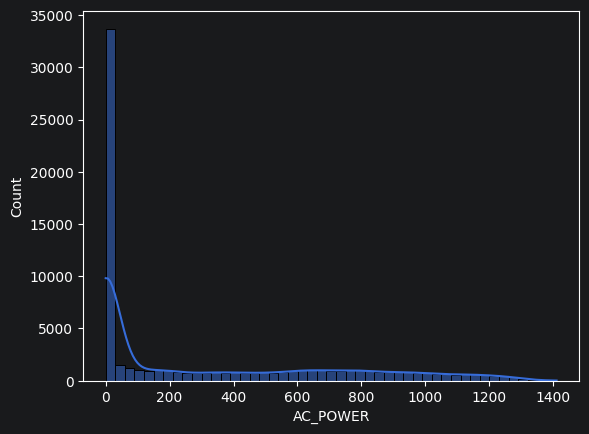

In [21]:
sns.histplot(merged_df['AC_POWER'], kde=True)
plt.show()

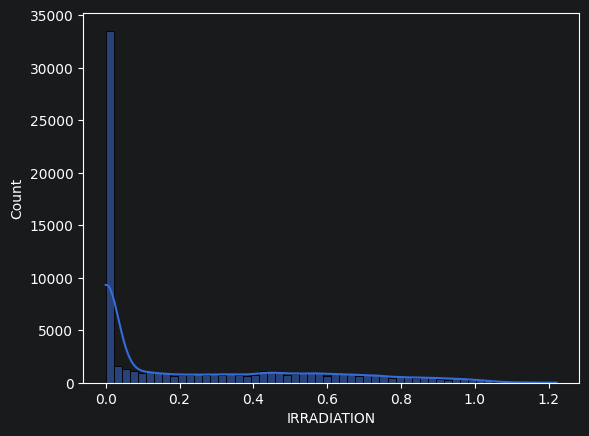

In [22]:
sns.histplot(merged_df['IRRADIATION'], kde=True)
plt.show()

<Axes: >

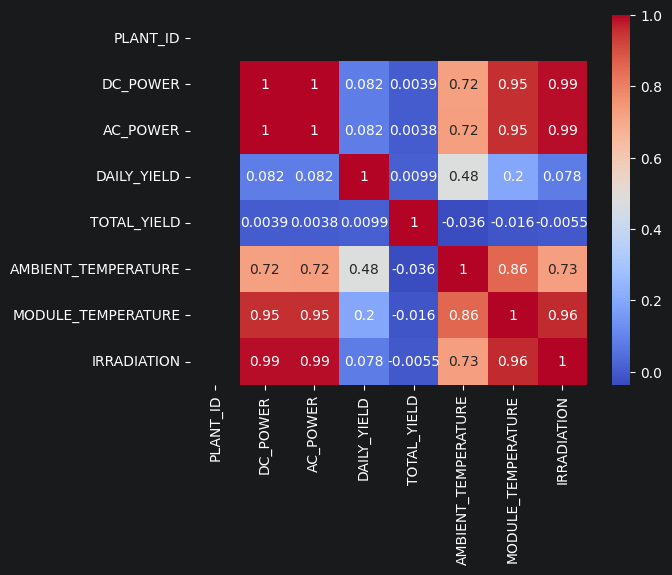

In [23]:
sns.heatmap(merged_df.corr(numeric_only=True),annot=True,cmap='coolwarm')

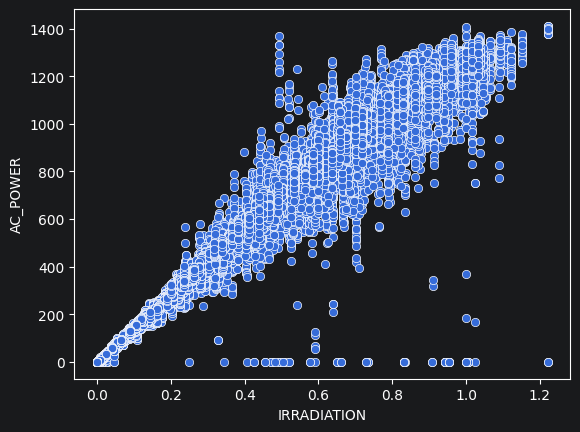

In [24]:
sns.scatterplot(
    data=merged_df,
    x='IRRADIATION',
    y='AC_POWER',
)
plt.show()

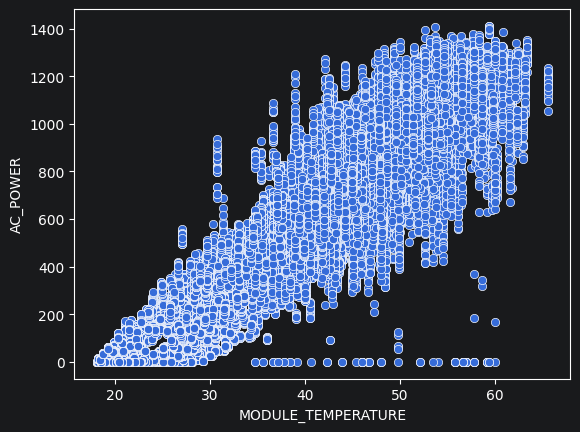

In [25]:
sns.scatterplot(
    data=merged_df,
    x='MODULE_TEMPERATURE',
    y='AC_POWER'
)
plt.show()

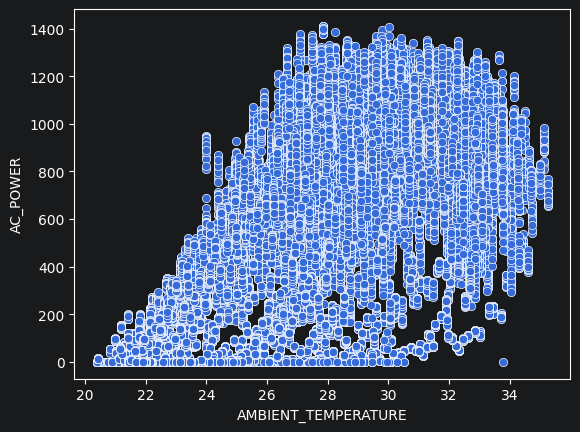

In [26]:
sns.scatterplot(
    data=merged_df,
    x='AMBIENT_TEMPERATURE',
    y='AC_POWER'
)
plt.show()


In [27]:
merged_df[
    (merged_df['IRRADIATION'] > 0.2) &
    (merged_df['AC_POWER'] == 0)
]

,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
815,2020-05-15 09:15:00,4135001,zVJPv84UY57bAof,0.0,0.0,711.0,7116862.0,HmiyD2TTLFNqkNe,27.988362,46.617706,0.344884
837,2020-05-15 09:30:00,4135001,zVJPv84UY57bAof,0.0,0.0,711.0,7116862.0,HmiyD2TTLFNqkNe,27.516728,39.136326,0.249248
18490,2020-05-24 15:15:00,4135001,zBIq5rxdHJRwDNY,0.0,0.0,6464.0,6410945.0,HmiyD2TTLFNqkNe,33.761304,54.006864,0.476600
20103,2020-05-25 10:15:00,4135001,ih0vzX44oOqAx2f,0.0,0.0,1795.0,6258289.0,HmiyD2TTLFNqkNe,29.217751,53.501414,0.834157
46675,2020-06-07 12:15:00,4135001,bvBOhCH3iADSZry,0.0,0.0,3551.0,6476675.0,HmiyD2TTLFNqkNe,28.748334,59.987771,1.024229
...,...,...,...,...,...,...,...,...,...,...,...
61591,2020-06-14 13:45:00,4135001,bvBOhCH3iADSZry,0.0,0.0,2378.0,6520020.0,HmiyD2TTLFNqkNe,27.048904,47.960231,0.906615
61602,2020-06-14 14:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,2402.0,6466065.0,HmiyD2TTLFNqkNe,27.848916,59.386079,1.221652
61613,2020-06-14 14:00:00,4135001,bvBOhCH3iADSZry,0.0,0.0,2378.0,6520020.0,HmiyD2TTLFNqkNe,27.848916,59.386079,1.221652
65714,2020-06-16 12:30:00,4135001,zBIq5rxdHJRwDNY,0.0,0.0,3480.0,6575313.0,HmiyD2TTLFNqkNe,27.964037,45.408554,0.483400


In [28]:
merged_df.drop(
    columns=['PLANT_ID', 'SOURCE_KEY_x', 'SOURCE_KEY_y'],
    inplace=True
)

In [29]:
merged_df

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,0.000,6259559.0,25.184316,22.857507,0.0
1,2020-05-15 00:00:00,0.0,0.0,0.000,6183645.0,25.184316,22.857507,0.0
2,2020-05-15 00:00:00,0.0,0.0,0.000,6987759.0,25.184316,22.857507,0.0
3,2020-05-15 00:00:00,0.0,0.0,0.000,7602960.0,25.184316,22.857507,0.0
4,2020-05-15 00:00:00,0.0,0.0,0.000,7158964.0,25.184316,22.857507,0.0
...,...,...,...,...,...,...,...,...
68769,2020-06-17 23:45:00,0.0,0.0,5967.000,7287002.0,21.909288,20.427972,0.0
68770,2020-06-17 23:45:00,0.0,0.0,5147.625,7028601.0,21.909288,20.427972,0.0
68771,2020-06-17 23:45:00,0.0,0.0,5819.000,7251204.0,21.909288,20.427972,0.0
68772,2020-06-17 23:45:00,0.0,0.0,5817.000,6583369.0,21.909288,20.427972,0.0


In [30]:
# splitting x nd y

In [31]:
x = merged_df[
    [
        'AMBIENT_TEMPERATURE',
        'MODULE_TEMPERATURE',
        'IRRADIATION'
    ]
]

y = merged_df['AC_POWER']

In [32]:
# train_test_split

In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [34]:
print(x_train.shape,y_train.shape)

(55019, 3) (55019,)


In [35]:
lr_model = LinearRegression()
lr_model.fit(x_train,y_train)
y_pred = lr_model.predict(x_test)

In [36]:
score = r2_score(y_test,y_pred)
print(score)

0.9800288894346422


In [37]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)

MAE = 26.30905127625148
MSE = 3081.630731049852
RMSE = 55.51243762482289


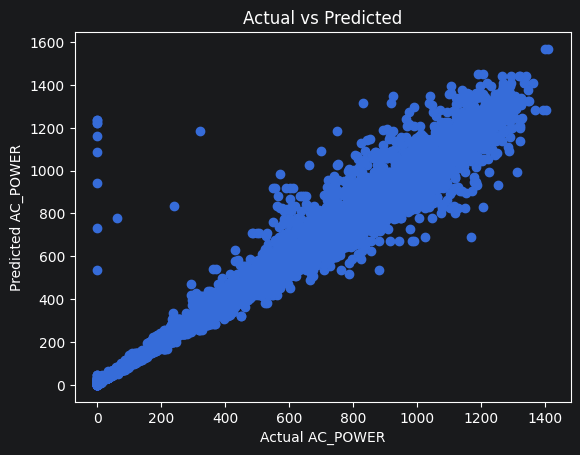

In [38]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual AC_POWER")
plt.ylabel("Predicted AC_POWER")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
# Input Testing

In [43]:
amb = float(input("Ambient Temperature: "))
mod = float(input("Module Temperature: "))
irr = float(input("Irradiation: "))

new_data = pd.DataFrame({
    'AMBIENT_TEMPERATURE':[amb],
    'MODULE_TEMPERATURE':[mod],
    'IRRADIATION':[irr]
})

prediction = lr_model.predict(new_data)

print("Predicted AC Power:", prediction[0])

Predicted AC Power: 1129.2983185964767
